In [ ]:
install.packages("sqldf")
install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(sqldf)
library(ggplot2)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



In [ ]:
unzip("/content/northstar_dataset (2).zip",
      exdir="/content/northstar_dataset_unzipped")

In [ ]:
orders <- read.csv("/content/northstar_dataset_unzipped/northstar_dataset/orders.csv")
head(orders)

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>
1,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
2,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
3,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
4,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
5,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0
6,O00006,C0437,Retail,2024-08-05 04:55:00,1,CENTRAL,East,High,151.44,Web,1


In [ ]:
result <- sqldf("
SELECT pickup_zone,
COUNT(*) as total_orders
FROM orders
GROUP BY pickup_zone
ORDER BY total_orders DESC
")

print(result)

   pickup_zone total_orders
1         East          104
2        South          103
3         EAST          103
4    RiverSide           86
5      Airport           85
6         WEST           84
7          Ctr           80
8      Central           79
9      CENTRAL           79
10       SOUTH           78
11        West           71
12   Riverside           65
13       north           64
14       NORTH           60
15     AIRPORT           59
16       North           50


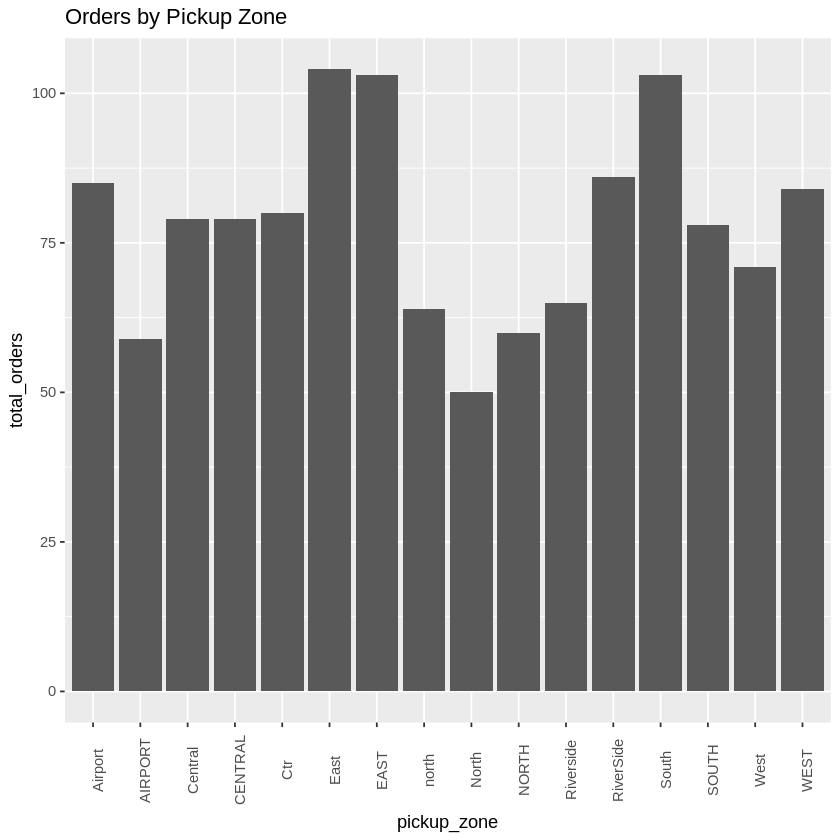

In [ ]:
ggplot(result, aes(x=pickup_zone, y=total_orders)) +
geom_bar(stat='identity') +
theme(axis.text.x = element_text(angle=90)) +
ggtitle('Orders by Pickup Zone')